In [1]:
import os
import re
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime

import seaborn as sns
from matplotlib import pyplot as plt


from patsy import dmatrices
import bambi as bmb
import arviz as az
from scipy.stats import chi2
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import display
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from util import *

sns.set_palette('colorblind')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [3]:
msnbc_urls = [
    "https://www.instagram.com/msnbc/reel/DQz6GiKkqD-/",
    "https://www.instagram.com/msnbc/reel/DQzvigyiu3R/",
    "https://www.instagram.com/msnbc/reel/DQzaxBeisq2/",
    "https://www.instagram.com/msnbc/reel/DQzOhJyil7B/",
    "https://www.instagram.com/msnbc/reel/DQx_MsXDdqz/",
    "https://www.instagram.com/reel/DQx6d6TDFvD/",
    "https://www.instagram.com/reel/DQxz17nkXAu/",
    "https://www.instagram.com/reel/DQxxwsjEQxy/",
    "https://www.instagram.com/reel/DQxf5uvERD0/",
    "https://www.instagram.com/reel/DQxc21kkqwR/",
]

huffpost_urls = [
    "https://www.instagram.com/huffpost/reel/DQzSuMQARR0/",
    "https://www.instagram.com/huffpost/p/DQxLW-PEns-/",
    "https://www.instagram.com/huffpost/reel/DQxARFuAbt-/",
    "https://www.instagram.com/huffpost/reel/DQw6Qa_kWgY/",
    "https://www.instagram.com/huffpost/reel/DQw5_xHkWod/",
    "https://www.instagram.com/huffpost/reel/DQwbCxQjQNQ/",
    "https://www.instagram.com/huffpost/p/DQu2w59E9t-/",
    "https://www.instagram.com/huffpost/reel/DQvEm2FDCmz/",
    "https://www.instagram.com/huffpost/p/DQuw7U7D322/",
    "https://www.instagram.com/p/DQujjUrk61E/"
]

cnn_urls = [
    "https://www.instagram.com/reel/DQ0VgDjjx7K/",
    "https://www.instagram.com/p/DQ0LWj6jue3/",
    "https://www.instagram.com/reel/DQz7vqJiEUj/",
    "https://www.instagram.com/reel/DQznNr7gp1F/",
    "https://www.instagram.com/reel/DQzgXgPgPmN/",
    "https://www.instagram.com/reel/DQzNYM8ARN3/",
    "https://www.instagram.com/reel/DQzEp0pChCY/",
    "https://www.instagram.com/reel/DQy-AdiCcH_/",
    "https://www.instagram.com/reel/DQyzpQVjga4/",
    "https://www.instagram.com/reel/DQypWvmDoge/"
]

washingtonpost_urls = [
    "https://www.instagram.com/washingtonpost/p/DQ0JgL9DqcC/",
    "https://www.instagram.com/washingtonpost/p/DQz7wRODMr8/",
    "https://www.instagram.com/washingtonpost/p/DQzuD3fFJcu/",
    "https://www.instagram.com/washingtonpost/reel/DQzh-t0DSAJ/",
    "https://www.instagram.com/washingtonpost/reel/DQzgTDHAcKl/",
    "https://www.instagram.com/p/DQzZihPDiQv/",
    "https://www.instagram.com/reel/DQzSo12D1fJ/",
    "https://www.instagram.com/reel/DQzLtq3ARq3/",
    "https://www.instagram.com/p/DQxxk6BDvZh/",
    "https://www.instagram.com/p/DQxqaCpDcHC/"
]

forbes_urls = [
    "https://www.instagram.com/forbes/p/DQ0Ck-lgUxt/",
    "https://www.instagram.com/forbes/p/DQz0444AWAd/",
    "https://www.instagram.com/forbes/p/DQzgP9_gcjC/",
    "https://www.instagram.com/p/DQzUOiGAblX/",
    "https://www.instagram.com/p/DQzLpqJDxMD/",
    "https://www.instagram.com/p/DQzFWzxkT-c/",
    "https://www.instagram.com/p/DQxdypCDPF2/",
    "https://www.instagram.com/p/DQxOpmbkn_b/",
    "https://www.instagram.com/p/DQxFjBJj4gS/",
    "https://www.instagram.com/p/DQxElAzD6aK/"
]

thehill_urls = [
    "https://www.instagram.com/thehill/p/DQzfVDcE3YB/",
    "https://www.instagram.com/thehill/p/DQxg1ufkeqR/",
    "https://www.instagram.com/thehill/reel/DQxViLFEdQ5/",
    "https://www.instagram.com/thehill/p/DQw1LZxEwrn/",
    "https://www.instagram.com/thehill/p/DQwgkZxD2Ug/",
    "https://www.instagram.com/thehill/reel/DQvAK9hEeWU/",
    "https://www.instagram.com/thehill/p/DQunQLokn-7/",
    "https://www.instagram.com/thehill/reel/DQuNa5zEeiR/",
    "https://www.instagram.com/thehill/p/DQt9lxsjumG/",
    "https://www.instagram.com/reel/DQrpC35EXqn/"
]

washingtontimes_urls = [
    "https://www.instagram.com/washtimes/p/DQz0CxJExjr/",
    "https://www.instagram.com/washtimes/p/DQzcWsGkg8C/",
    "https://www.instagram.com/washtimes/p/DQxHICQE_29/",
    "https://www.instagram.com/washtimes/p/DQw_V8sE6ZH/",
    "https://www.instagram.com/washtimes/p/DQw3jz6k0L6/",
    "https://www.instagram.com/washtimes/p/DQwvq-dktiv/",
    "https://www.instagram.com/washtimes/p/DQwn4b2EzCR/",
    "https://www.instagram.com/washtimes/p/DQwgGZ2jQck/",
    "https://www.instagram.com/washtimes/p/DQvCB1iEwBa/",
    "https://www.instagram.com/washtimes/reel/DQu5zA1CL3U/"
]

nypost_urls = [
    "https://www.instagram.com/p/DQ0Jd_SAc4Z/",
    "https://www.instagram.com/p/DQ0GBAngWyx/",
    "https://www.instagram.com/reel/DQ0ETkoDtLN/",
    "https://www.instagram.com/p/DQ0ClEugU1r/",
    "https://www.instagram.com/p/DQz_JRkAWr9/",
    "https://www.instagram.com/reel/DQz9kQIDZOc/",
    "https://www.instagram.com/p/DQz70tPAQTn/",
    "https://www.instagram.com/p/DQz4Y1Xgadc/",
    "https://www.instagram.com/reel/DQz2rWGEkpe/",
    "https://www.instagram.com/p/DQz09vagSe1/"
]

foxnews_urls = [
    "https://www.instagram.com/reel/DQ0V_qAEfwE/",
    "https://www.instagram.com/reel/DQ0UdiODE-2/",
    "https://www.instagram.com/reel/DQ0UNIZD3rv/",
    "https://www.instagram.com/reel/DQ0OfgWAswZ/",
    "https://www.instagram.com/reel/DQ0OAwCk91U/",
    "https://www.instagram.com/reel/DQ0GaXEjofE/",
    "https://www.instagram.com/reel/DQ0ClztkmYz/",
    "https://www.instagram.com/p/DQ0AYUTkvh4/",
    "https://www.instagram.com/p/DQz8ZTUjJ4s/",
    "https://www.instagram.com/reel/DQz8UW2j4TQ/"
]

breitbart_urls = [
    "https://www.instagram.com/p/DQ0P_UtDFLj/",
    "https://www.instagram.com/p/DQ0ImR1DaM0/",
    "https://www.instagram.com/p/DQz28XJkuQV/",
    "https://www.instagram.com/p/DQzkN12CUZQ/",
    "https://www.instagram.com/reel/DQzXuPOkgOo/",
    "https://www.instagram.com/p/DQzR5CjkQxS/",
    "https://www.instagram.com/p/DQzJCenDSPC/",
    "https://www.instagram.com/p/DQy1VfcETEi/",
    "https://www.instagram.com/reel/DQxZ3LCkvgh/",
    "https://www.instagram.com/p/DQxfi8JjVGb/"
]

all_urls = {
    'msnbc': msnbc_urls,
    'huffpost': huffpost_urls,
    'cnn': cnn_urls,
    'washingtonpost': washingtonpost_urls,
    'forbes': forbes_urls,
    'thehill': thehill_urls,
    'washingtontimes': washingtontimes_urls,
    'nypost': nypost_urls,
    'foxnews': foxnews_urls,
    'breitbart': breitbart_urls
}

In [4]:
all_crawls = ['ny_1', 'texas_1',
              'male_dem_ny_1', 'male_dem_texas_1',
              'male_rep_ny_1', 'male_rep_texas_1',
              'female_dem_ny_1', 'female_dem_texas_1',
              'female_rep_ny_1', 'female_rep_texas_1']

# all_crawls = ['ny_1',
#               'male_dem_ny_1',
#               'male_rep_ny_1',
#               'female_dem_ny_1',
#               'female_rep_ny_1']

file_path = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/new'

### Merging and preprocessing

In [5]:
dfs = {}
for crawl in all_crawls:
    temp_list = []
    for account in all_urls.keys():

        accountfiles = os.listdir(f'{file_path}/{crawl}/{account}')
        file_ids = list({re.split(r'_(comments|timestamps)', fp)[0] for fp in accountfiles})

        for id_ in file_ids:

            if f'{id_}_comments.json' in accountfiles and f'{id_}_timestamps.json' in accountfiles:
                with open(f'{file_path}/{crawl}/{account}/{id_}_comments.json', 'r') as f:
                    comments = json.load(f)
                with open(f'{file_path}/{crawl}/{account}/{id_}_timestamps.json', 'r') as f:
                    timestamps = json.load(f)
                
                caption, comments, likes = clean_comments(comments)

                if id_ == 'DRVQXcWAaaw':
                    idx = comments.index('authoryuccaharris')
                    comments = comments[:idx+1] + [' '] + comments[idx+1:]

                comments_map = {}

                if len(comments) == 2*len(timestamps):

                    if len(comments) % 2 == 0:

                        usernames = comments[::2]
                        comments_text = comments[1::2]

                        
                        for u, c, t in zip(usernames, comments_text, timestamps):
                            comments_map[(u, c)] = t

                        idx = 0
                        for c, v in comments_map.items():
                            temp_dict = {'account': account,
                                         'urlid': id_,
                                         'caption': caption,
                                         'comment_num': idx,
                                         f'{crawl}_comment': c,
                                         f'{crawl}_timestamp': v,
                                         'likes': likes}
                            idx += 1
                            temp_list.append(temp_dict)

                else:
                    print(f'comemnts-timestamps lenght mismatch')
            else:
                with open(f'{file_path}/{crawl}/{account}/{id_}_comments.json', 'r') as f:
                    comments = json.load(f)

                caption, comments, likes = clean_comments(comments)

                if len(comments) != 0:
                    print('no timestamp file and len(comments) != 0')

    df = pd.DataFrame(temp_list)
    dfs[crawl] = df

In [6]:
for crawl, df in dfs.items():
    print(f'{crawl}: {df.shape}')

ny_1: (1188, 7)
texas_1: (1173, 7)
male_dem_ny_1: (1062, 7)
male_dem_texas_1: (1091, 7)
male_rep_ny_1: (1155, 7)
male_rep_texas_1: (1082, 7)
female_dem_ny_1: (1087, 7)
female_dem_texas_1: (1085, 7)
female_rep_ny_1: (1089, 7)
female_rep_texas_1: (1090, 7)


In [7]:
for crawl, df in dfs.items():
    df.drop(columns=['caption', 'likes'], inplace=True, axis=1)

In [8]:
merged_df = dfs['ny_1'].copy()

for crawl, df in dfs.items():
    if crawl == 'ny_1':
        continue
    print(crawl)
    merged_df = pd.merge(merged_df, df, how='outer', on=['account', 'urlid', 'comment_num'])

texas_1
male_dem_ny_1
male_dem_texas_1
male_rep_ny_1
male_rep_texas_1
female_dem_ny_1
female_dem_texas_1
female_rep_ny_1
female_rep_texas_1


In [9]:
merged_df = merged_df[merged_df['comment_num'] <= 9]

In [10]:
merged_df

,account,urlid,comment_num,ny_1_comment,ny_1_timestamp,texas_1_comment,texas_1_timestamp,male_dem_ny_1_comment,male_dem_ny_1_timestamp,male_dem_texas_1_comment,male_dem_texas_1_timestamp,male_rep_ny_1_comment,male_rep_ny_1_timestamp,male_rep_texas_1_comment,male_rep_texas_1_timestamp,female_dem_ny_1_comment,female_dem_ny_1_timestamp,female_dem_texas_1_comment,female_dem_texas_1_timestamp,female_rep_ny_1_comment,female_rep_ny_1_timestamp,female_rep_texas_1_comment,female_rep_texas_1_timestamp
0,breitbart,DRV5wtFDGsb,0,"(andreasblimp, Why can't people respect the de...",2025-11-22T03:08:22.000Z,"(andreasblimp, Why can't people respect the de...",2025-11-22T03:08:22.000Z,"(andreasblimp, Why can't people respect the de...",2025-11-22T03:08:22.000Z,"(andreasblimp, Why can't people respect the de...",2025-11-22T03:08:22.000Z,"(andreasblimp, Why can't people respect the de...",2025-11-22T03:08:22.000Z,"(andreasblimp, Why can't people respect the de...",2025-11-22T03:08:22.000Z,"(andreasblimp, Why can't people respect the de...",2025-11-22T03:08:22.000Z,"(andreasblimp, Why can't people respect the de...",2025-11-22T03:08:22.000Z,"(andreasblimp, Why can't people respect the de...",2025-11-22T03:08:22.000Z,"(andreasblimp, Why can't people respect the de...",2025-11-22T03:08:22.000Z
1,breitbart,DRV5wtFDGsb,1,"(brett_selacki, A creature really is he a crea...",2025-11-22T02:54:01.000Z,"(brett_selacki, A creature really is he a crea...",2025-11-22T02:54:01.000Z,"(happenings_25, Why did Bannon leave Breitbart...",2025-11-24T02:59:34.000Z,"(happenings_25, Why did Bannon leave Breitbart...",2025-11-24T02:59:34.000Z,"(brett_selacki, A creature really is he a crea...",2025-11-22T02:54:01.000Z,"(brett_selacki, A creature really is he a crea...",2025-11-22T02:54:01.000Z,"(happenings_25, Why did Bannon leave Breitbart...",2025-11-24T02:59:34.000Z,"(happenings_25, Why did Bannon leave Breitbart...",2025-11-24T02:59:34.000Z,"(happenings_25, Why did Bannon leave Breitbart...",2025-11-24T02:59:34.000Z,"(happenings_25, Why did Bannon leave Breitbart...",2025-11-24T02:59:34.000Z
2,breitbart,DRV5wtFDGsb,2,"(y_now_que, Trump was literally swooning over ...",2025-11-22T02:46:38.000Z,"(y_now_que, Trump was literally swooning over ...",2025-11-22T02:46:38.000Z,"(talldarkprince, The MAGA movement lost its wa...",2025-11-22T03:53:48.000Z,"(talldarkprince, The MAGA movement lost its wa...",2025-11-22T03:53:48.000Z,"(happenings_25, Why did Bannon leave Breitbart...",2025-11-24T02:59:34.000Z,"(happenings_25, Why did Bannon leave Breitbart...",2025-11-24T02:59:34.000Z,"(ariabkowalskin, Interesting perspective on th...",2025-11-22T02:51:36.000Z,"(ariabkowalskin, Interesting perspective on th...",2025-11-22T02:51:36.000Z,"(talldarkprince, The MAGA movement lost its wa...",2025-11-22T03:53:48.000Z,"(talldarkprince, The MAGA movement lost its wa...",2025-11-22T03:53:48.000Z
3,breitbart,DRV5wtFDGsb,3,"(happenings_25, Why did Bannon leave Breitbart...",2025-11-24T02:59:34.000Z,"(happenings_25, Why did Bannon leave Breitbart...",2025-11-24T02:59:34.000Z,"(ariabkowalskin, Interesting perspective on th...",2025-11-22T02:51:36.000Z,"(ariabkowalskin, Interesting perspective on th...",2025-11-22T02:51:36.000Z,"(talldarkprince, The MAGA movement lost its wa...",2025-11-22T03:53:48.000Z,"(talldarkprince, The MAGA movement lost its wa...",2025-11-22T03:53:48.000Z,"(talldarkprince, The MAGA movement lost its wa...",2025-11-22T03:53:48.000Z,"(talldarkprince, The MAGA movement lost its wa...",2025-11-22T03:53:48.000Z,"(ariabkowalskin, Interesting perspective on th...",2025-11-22T02:51:36.000Z,"(ariabkowalskin, Interesting perspective on th...",2025-11-22T02:51:36.000Z
4,breitbart,DRV5wtFDGsb,4,"(ariabkowalskin, Interesting perspective on th...",2025-11-22T02:51:36.000Z,"(ariabkowalskin, Interesting perspective on th...",2025-11-22T02:51:36.000Z,NaN,NaN,NaN,NaN,"(ariabkowalskin, Interesting perspective on th...",2025-11-22T02:51:36.000Z,"(ariabkowalskin, Interesting perspective on t

In [11]:
temp_list = []
for account in all_urls.keys():
    urlids = merged_df[merged_df['account'] == account]['urlid'].unique()

    for urlid in urlids:

        temp = merged_df[(merged_df['account'] == account) & (merged_df['urlid'] == urlid)].copy()
        unique_comments = {}

        for col in all_crawls:
            for comment, timestamp in zip(temp[f'{col}_comment'], temp[f'{col}_timestamp']):
                if pd.isna(comment):
                    continue
                if comment not in unique_comments:
                    unique_comments[comment] = timestamp
                else:
                    if timestamp != unique_comments[comment]:
                        print('mismatch timestamp for same comment')

        for comment, timestamp in unique_comments.items():
            unique_comments[comment] = datetime.fromisoformat(timestamp)

        sorted_comments = sorted(unique_comments.items(), key=lambda x: x[1], reverse=True)
        idx = 0
        for comment, timestamp in sorted_comments:
            temp_list.append({'account': account,
                              'urlid': urlid,
                              'comment_num': idx,
                              'chronological_comment': comment,
                              'chronological_timestamp': timestamp})
            idx += 1
            
temp_df = pd.DataFrame(temp_list)

In [12]:
temp_df

,account,urlid,comment_num,chronological_comment,chronological_timestamp
0,msnbc,DRV0xJXETpL,0,"(melissascott2660, idk what she's up to, but i...",2025-11-22 03:17:26+00:00
1,msnbc,DRV0xJXETpL,1,"(bayesandy56, I was just started to like her🥴)",2025-11-22 02:44:38+00:00
2,msnbc,DRV0xJXETpL,2,"(jus10avalos, Hooray!)",2025-11-22 02:41:31+00:00
3,msnbc,DRV0xJXETpL,3,"(char1ens, I see what you’re doing lord, but t...",2025-11-22 02:40:42+00:00
4,msnbc,DRV0xJXETpL,4,"(keep_tryna_figure_me_out, This is wonderful —...",2025-11-22 02:18:53+00:00
...,...,...,...,...,...
1151,breitbart,DRZPF4PDjqw,9,"(calzarettaprovidence, 👏👏👏👏👏👏👏)",2025-11-23 10:37:40+00:00
1152,breitbart,DRZPF4PDjqw,10,"(battle51968, Adios amigos)",2025-11-23 10:18:55+00:00
1153,breitbart,DRZPF4PDjqw,11,"(travellingtrunk101, 👏👏👏👏👏👏👏)",2025-11-23 10:14:35+00:00
1154,breitbart,DRZPF4PDjqw,12,"(jeanne.sims.524, All discussing)",2025-11-23 09:51:27+00:00


In [13]:
merged_df = pd.merge(merged_df, temp_df, how='outer', on=['account', 'urlid', 'comment_num'])

In [14]:
merged_df.shape

(1156, 25)

In [15]:
merged_df.drop(columns=[x for x in merged_df.columns if 'timestamp' in x], inplace=True)
merged_df.head()

,account,urlid,comment_num,ny_1_comment,texas_1_comment,male_dem_ny_1_comment,male_dem_texas_1_comment,male_rep_ny_1_comment,male_rep_texas_1_comment,female_dem_ny_1_comment,female_dem_texas_1_comment,female_rep_ny_1_comment,female_rep_texas_1_comment,chronological_comment
0,breitbart,DRV5wtFDGsb,0,"(andreasblimp, Why can't people respect the de...","(andreasblimp, Why can't people respect the de...","(andreasblimp, Why can't people respect the de...","(andreasblimp, Why can't people respect the de...","(andreasblimp, Why can't people respect the de...","(andreasblimp, Why can't people respect the de...","(andreasblimp, Why can't people respect the de...","(andreasblimp, Why can't people respect the de...","(andreasblimp, Why can't people respect the de...","(andreasblimp, Why can't people respect the de...","(happenings_25, Why did Bannon leave Breitbart..."
1,breitbart,DRV5wtFDGsb,1,"(brett_selacki, A creature really is he a crea...","(brett_selacki, A creature really is he a crea...","(happenings_25, Why did Bannon leave Breitbart...","(happenings_25, Why did Bannon leave Breitbart...","(brett_selacki, A creature really is he a crea...","(brett_selacki, A creature really is he a crea...","(happenings_25, Why did Bannon leave Breitbart...","(happenings_25, Why did Bannon leave Breitbart...","(happenings_25, Why did Bannon leave Breitbart...","(happenings_25, Why did Bannon leave Breitbart...","(talldarkprince, The MAGA movement lost its wa..."
2,breitbart,DRV5wtFDGsb,2,"(y_now_que, Trump was literally swooning over ...","(y_now_que, Trump was literally swooning over ...","(talldarkprince, The MAGA movement lost its wa...","(talldarkprince, The MAGA movement lost its wa...","(happenings_25, Why did Bannon leave Breitbart...","(happenings_25, Why did Bannon leave Breitbart...","(ariabkowalskin, Interesting perspective on th...","(ariabkowalskin, Interesting perspective on th...","(talldarkprince, The MAGA movement lost its wa...","(talldarkprince, The MAGA movement lost its wa...","(andreasblimp, Why can't people respect the de..."
3,breitbart,DRV5wtFDGsb,3,"(happenings_25, Why did Bannon leave Breitbart...","(happenings_25, Why did Bannon leave Breitbart...","(ariabkowalskin, Interesting perspective on th...","(ariabkowalskin, Interesting perspective on th...","(talldarkprince, The MAGA movement lost its wa...","(talldarkprince, The MAGA movement lost its wa...","(talldarkprince, The MAGA movement lost its wa...","(talldarkprince, The MAGA movement lost its wa...","(ariabkowalskin, Interesting perspective on th...","(ariabkowalskin, Interesting perspective on th...","(brett_selacki, A creature really is he a crea..."
4,breitbart,DRV5wtFDGsb,4,"(ariabkowalskin, Interesting perspective on th...","(ariabkowalskin, Interesting perspective on th...",NaN,NaN,"(ariabkowalskin, Interesting perspective on th...","(ariabkowalskin, Interesting perspective on th...",NaN,NaN,NaN,NaN,"(ariabkowalskin, Interesting perspective on th..."


### Plotting differences

In [77]:
crawl1 = 'ny_1'
crawl2 = 'male_rep_ny_1'

account_fprops_ranking_unpres, account_fprops_ranking_pres, temp_df = compute_fprops(crawl1, crawl2, merged_df, all_urls)

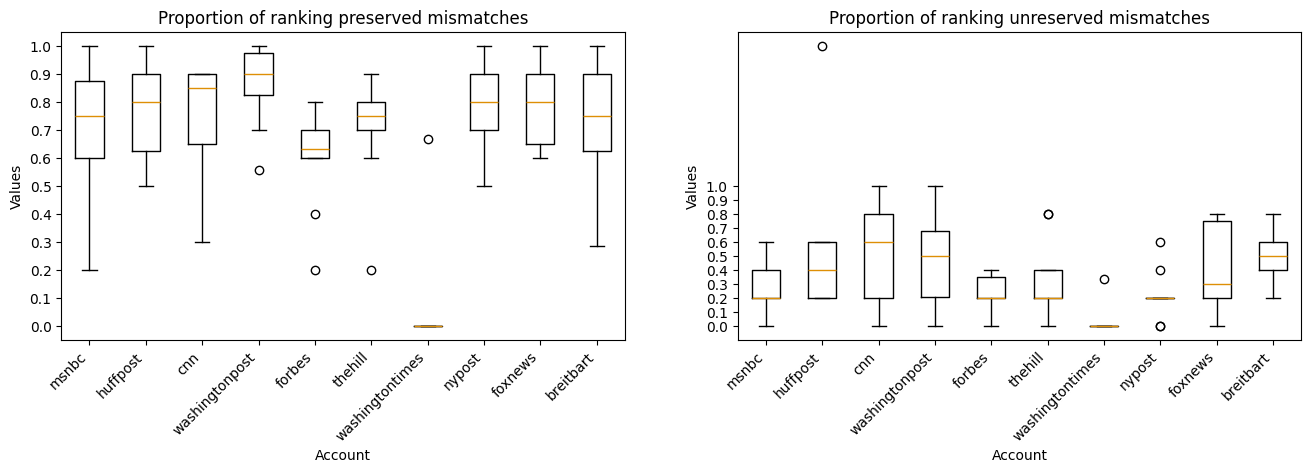

In [78]:
accounts = list(account_fprops_ranking_pres.keys())
values_pres = [account_fprops_ranking_pres[acc] for acc in accounts]
values_unpres = [account_fprops_ranking_unpres[acc] for acc in accounts]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

ax1.boxplot(values_pres, tick_labels=accounts)
ax1.set_title("Proportion of ranking preserved mismatches")
ax1.set_xlabel("Account")
ax1.set_ylabel("Values")
ax1.set_xticks(range(1, 11))
ax1.set_xticklabels(accounts, rotation=45, ha='right')
ax1.set_yticks(np.arange(0, 1.1, 0.1))

ax2.boxplot(values_unpres, tick_labels=accounts)
ax2.set_title("Proportion of ranking unreserved mismatches")
ax2.set_xlabel("Account")
ax2.set_ylabel("Values")
ax2.set_xticks(range(1, 11))
ax2.set_xticklabels(accounts, rotation=45, ha='right')
ax2.set_yticks(np.arange(0, 1.1, 0.1))

plt.show()

### Regression

In [49]:
reg_df = pd.DataFrame(columns=['account', 'urlid', 'gender', 'ideology', 'fcount_no_rank', 'ftrials_no_rank', 'fcount_rank', 'ftrials_rank'])

temp_list = []
for crawl1 in ['chronological']:
    for crawl2 in tqdm(all_crawls):

        if crawl1 == crawl2:
            continue

        temp_dict = {}

        _, _, merged_df = compute_fprops(crawl1, crawl2, merged_df, all_urls)
        temp_df = merged_df[['account', 'urlid', 'fcount_no_rank', 'ftrials_no_rank', 'fcount_rank', 'ftrials_rank']].drop_duplicates()

        location = "none"
        if 'ny' in crawl2:
            location = 'ny'
        elif 'texas' in crawl2:
            location = 'texas'

        gender = "none"
        # gender = None
        if 'female' in crawl2:
            gender = 'female'
        elif 'male' in crawl2:
            gender = 'male'

        ideology = "none"
        # ideology = None
        if 'dem' in crawl2:
            ideology = 'dem'
        elif 'rep' in crawl2:
            ideology = 'rep'

        gender_ideology = gender + '_' + ideology + '_' + location

        temp_dict['location'] = location
        temp_dict['gender'] = gender
        temp_dict['ideology'] = ideology
        temp_dict['gender_ideology'] = gender_ideology

        for index, row in temp_df.iterrows():
            temp_dict['urlid'] = row['urlid']
            temp_dict['account'] = row['account']
            temp_dict['fcount_no_rank'] = row['fcount_no_rank']
            temp_dict['ftrials_no_rank'] = row['ftrials_no_rank']
            temp_dict['fcount_rank'] = row['fcount_rank'] 
            temp_dict['ftrials_rank'] = row['ftrials_rank']
            temp_list.append(temp_dict.copy())


reg_df = pd.DataFrame(temp_list)        
reg_df.shape

100%|██████████| 10/10 [00:01<00:00,  8.56it/s]


(950, 10)

In [50]:
reg_df

,location,gender,ideology,gender_ideology,urlid,account,fcount_no_rank,ftrials_no_rank,fcount_rank,ftrials_rank
0,ny,none,none,none_none_ny,DRV5wtFDGsb,breitbart,0.0,7.0,5.0,7.0
1,ny,none,none,none_none_ny,DRWBiQXDG0H,breitbart,1.0,11.0,9.0,11.0
2,ny,none,none,none_none_ny,DRWXFT9DRtK,breitbart,4.0,14.0,9.0,14.0
3,ny,none,none,none_none_ny,DRWhnmjDo-i,breitbart,4.0,14.0,10.0,14.0
4,ny,none,none,none_none_ny,DRXIibxjFKK,breitbart,3.0,13.0,10.0,13.0
...,...,...,...,...,...,...,...,...,...,...
945,texas,female,rep,female_rep_texas,DRU66sgE9tl,washingtontimes,0.0,1.0,0.0,1.0
946,texas,female,rep,female_rep_texas,DRUjQ89EgPE,washingtontimes,1.0,3.0,0.0,3.0
947,texas,female,rep,female_rep_texas,DRVCly3k6Nf,washingtontimes,0.0,1.0,0.0,1.0
948,texas,female,rep,female_rep_texas,DRVKQFeE7hq,washingtontimes,0.0,2.0,0.0,2.0


In [51]:
reg_df.duplicated().sum()

np.int64(0)

In [52]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/News Sites US.xlsx', sheet_name='Sheet3')
accounts_data.head(3)

,account,political_ideology,reporting_quality,credibility,posts,followers,following
0,msnbc,Left,Mixed,Medium,16790,2400000,308
1,huffpost,Left,Mixed,Medium,12119,3300000,708
2,cnn,Center-Left,Mostly Factual,Medium,21936,21700000,289


In [53]:
reg_df = pd.merge(reg_df, accounts_data, on='account', how='inner')
reg_df.shape

(950, 16)

In [54]:
reg_df['fcount_no_rank'] = reg_df['fcount_no_rank'].astype(int)
reg_df['ftrials_no_rank'] = reg_df['ftrials_no_rank'].astype(int)
reg_df['fcount_rank'] = reg_df['fcount_rank'].astype(int)
reg_df['ftrials_rank'] = reg_df['ftrials_rank'].astype(int)

reg_df[reg_df['fcount_no_rank'] > reg_df['ftrials_no_rank']]
reg_df[reg_df['fcount_rank'] > reg_df['ftrials_rank']]

,location,gender,ideology,gender_ideology,urlid,account,fcount_no_rank,ftrials_no_rank,fcount_rank,ftrials_rank,political_ideology,reporting_quality,credibility,posts,followers,following


In [55]:
# reg_df["gender_ideology"] = pd.Categorical(
#     reg_df["gender_ideology"],
#     categories=["none_none", "female_dem", "female_rep", "male_dem", "male_rep"],
#     ordered=True
# )

for col in ["posts", "followers", "following"]:
    reg_df[col + "_z"] = (reg_df[col] - reg_df[col].mean()) / reg_df[col].std()


# reg_df["ideology"] = pd.Categorical(
#     reg_df["ideology"],
#     categories=["none", "dem", "rep"],
#     ordered=True
# )
# reg_df["gender"] = pd.Categorical(
#     reg_df["gender"],
#     categories=["none", "female", "male"],
#     ordered=True
# )
# reg_df["location"] = pd.Categorical(
#     reg_df["location"],
#     categories=["ny", "texas"],
#     ordered=True
# )


In [57]:
reg_df['gender_ideology'].value_counts()
# reg_df[['gender', 'ideology']].value_counts()

gender_ideology
none_none_ny        95
none_none_texas     95
male_dem_ny         95
male_dem_texas      95
male_rep_ny         95
male_rep_texas      95
female_dem_ny       95
female_dem_texas    95
female_rep_ny       95
female_rep_texas    95
Name: count, dtype: int64

In [58]:
reg_df.head()

,location,gender,ideology,gender_ideology,urlid,account,fcount_no_rank,ftrials_no_rank,fcount_rank,ftrials_rank,political_ideology,reporting_quality,credibility,posts,followers,following,posts_z,followers_z,following_z
0,ny,none,none,none_none_ny,DRV5wtFDGsb,breitbart,0,7,5,7,Right,Mixed,Low,34864,1800000,362,0.323517,-0.666177,0.463979
1,ny,none,none,none_none_ny,DRWBiQXDG0H,breitbart,1,11,9,11,Right,Mixed,Low,34864,1800000,362,0.323517,-0.666177,0.463979
2,ny,none,none,none_none_ny,DRWXFT9DRtK,breitbart,4,14,9,14,Right,Mixed,Low,34864,1800000,362,0.323517,-0.666177,0.463979
3,ny,none,none,none_none_ny,DRWhnmjDo-i,breitbart,4,14,10,14,Right,Mixed,Low,34864,1800000,362,0.323517,-0.666177,0.463979
4,ny,none,none,none_none_ny,DRXIibxjFKK,breitbart,3,13,10,13,Right,Mixed,Low,34864,1800000,362,0.323517,-0.666177,0.463979


In [59]:
reg_df[["posts", "followers", "following"]].corr()

,posts,followers,following
posts,1.000000,0.201278,-0.224578
followers,0.201278,1.000000,-0.141528
following,-0.224578,-0.141528,1.000000


In [60]:
reg_df[['gender', 'ideology']].value_counts()

gender  ideology
female  dem         190
        rep         190
male    dem         190
        rep         190
none    none        190
Name: count, dtype: int64

In [61]:
# formula = "fcount_no_rank ~ C(gender_ideology) + C(political_ideology) + C(location) + C(reporting_quality) + C(credibility) + posts + followers + following"
# formula = "fcount_no_rank ~ C(gender_ideology) + C(political_ideology) + C(location) + C(credibility) + posts + followers + following"
formula = "fcount_no_rank ~ C(gender_ideology) + C(political_ideology) + posts_z + followers_z + following_z"
# formula = "fcount_no_rank ~ C(gender_ideology) + posts_z + followers_z + following_z"
# formula = "fcount_no_rank ~ C(gender) + C(ideology) + C(political_ideology) + C(location) + C(reporting_quality) + C(credibility) + posts + followers + following" 
# formula = "fcount_no_rank ~ C(gender) + C(ideology) + C(political_ideology) + C(location) + C(credibility) + posts + followers + following" 
# formula = "fcount_no_rank ~ C(gender) + C(ideology) + C(political_ideology) + C(location) + posts_z + followers_z + following_z" 
get_vif(formula, reg_df)

,feature,VIF
1,C(gender_ideology)[T.female_dem_texas],1.800000
2,C(gender_ideology)[T.female_rep_ny],1.800000
4,C(gender_ideology)[T.male_dem_ny],1.800000
5,C(gender_ideology)[T.male_dem_texas],1.800000
9,C(gender_ideology)[T.none_none_texas],1.800000
8,C(gender_ideology)[T.none_none_ny],1.800000
3,C(gender_ideology)[T.female_rep_texas],1.800000
6,C(gender_ideology)[T.male_rep_ny],1.800000
7,C(gender_ideology)[T.male_rep_texas],1.800000
16,following_z,2.839364


In [36]:
# reg_df = reg_df[reg_df['fcount_no_rank'] < reg_df['ftrials_no_rank']]

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, gender_ideology, political_ideology, posts_z, followers_z, following_z, 1|account_sigma, 1|account_offset, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 177 seconds.


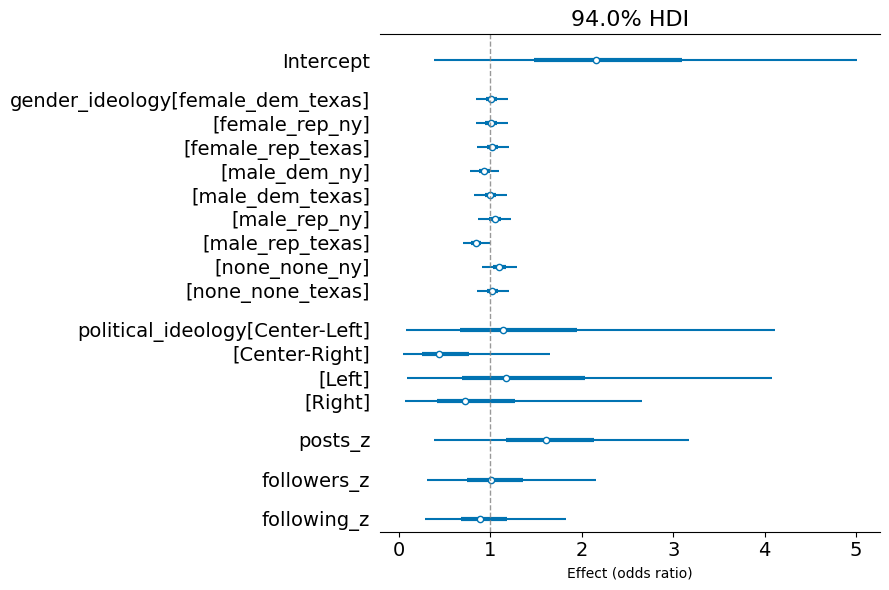

In [74]:
model = bmb.Model(
    "p(fcount_rank, ftrials_rank) ~ gender_ideology + political_ideology + posts_z + followers_z + following_z + (1|account) + (1|urlid)",
    # "p(fcount_no_rank, ftrials_no_rank) ~ gender + ideology + political_ideology + posts_z + followers_z + following_z + (1|account) + (1|urlid)",
    data=reg_df,
    family="binomial",
    dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.99,
    chains=4
)
az.summary(results)


az.summary(
    results,
    # var_names=["Intercept", "gender", "political_ideology", "location", "ideology"]
)

axes = az.plot_forest(
    results,
    var_names=["Intercept", "gender_ideology", "political_ideology",
               "posts_z", "followers_z", "following_z"],
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(9, 6),
    r_hat=False,
    ess=False,
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")

plt.tight_layout()
plt.show()

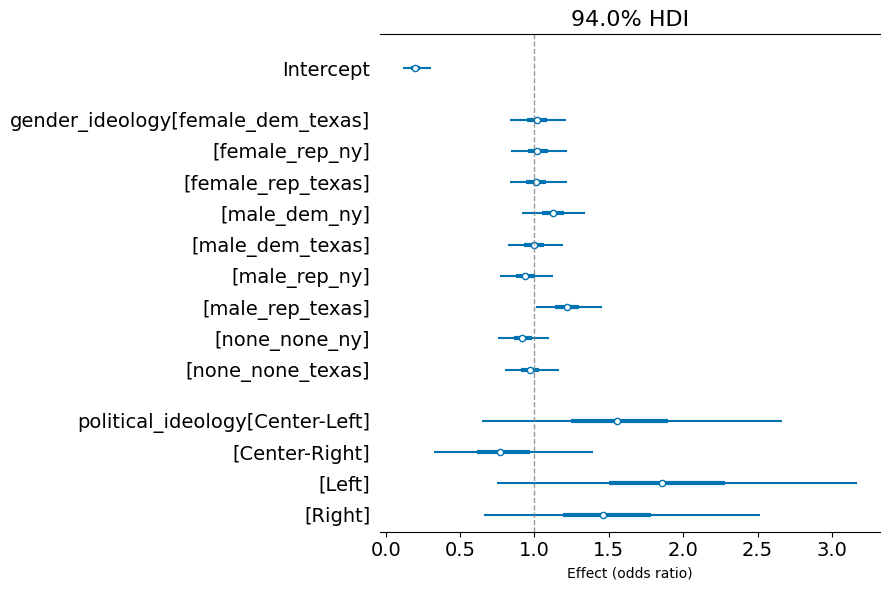

In [65]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ gender_ideology + political_ideology + (1|account) + (1|urlid)",
    # "p(fcount_no_rank, ftrials_no_rank) ~ gender + ideology + political_ideology + (1|account) + (1|urlid)",
    data=reg_df,
    family="binomial",
    dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.99,
    chains=4
)
az.summary(results)


az.summary(
    results,
    # var_names=["Intercept", "gender", "political_ideology", "location", "ideology"]
)

axes = az.plot_forest(
    results,
    var_names=["Intercept", "gender_ideology", "political_ideology"],
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(9, 6),
    r_hat=False,
    ess=False,
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")

plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, gender_ideology, posts_z, followers_z, following_z, 1|account_sigma, 1|account_offset, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 43 seconds.


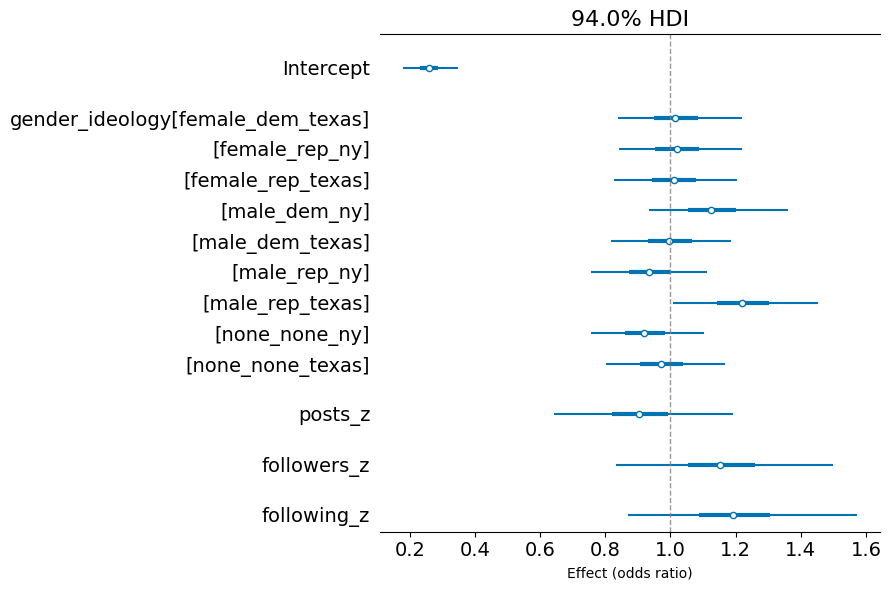

In [66]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ gender_ideology + posts_z + followers_z + following_z + (1|account) + (1|urlid)",
    data=reg_df,
    family="binomial",
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.99,
    chains=4
)
az.summary(results)


az.summary(
    results,
    # var_names=["Intercept", "gender", "political_ideology", "location", "ideology"]
)

axes = az.plot_forest(
    results,
    var_names=["Intercept", "gender_ideology",
               "posts_z", "followers_z", "following_z"],
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(9, 6),
    r_hat=False,
    ess=False,
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")

plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, gender_ideology, 1|account_sigma, 1|account_offset, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 40 seconds.


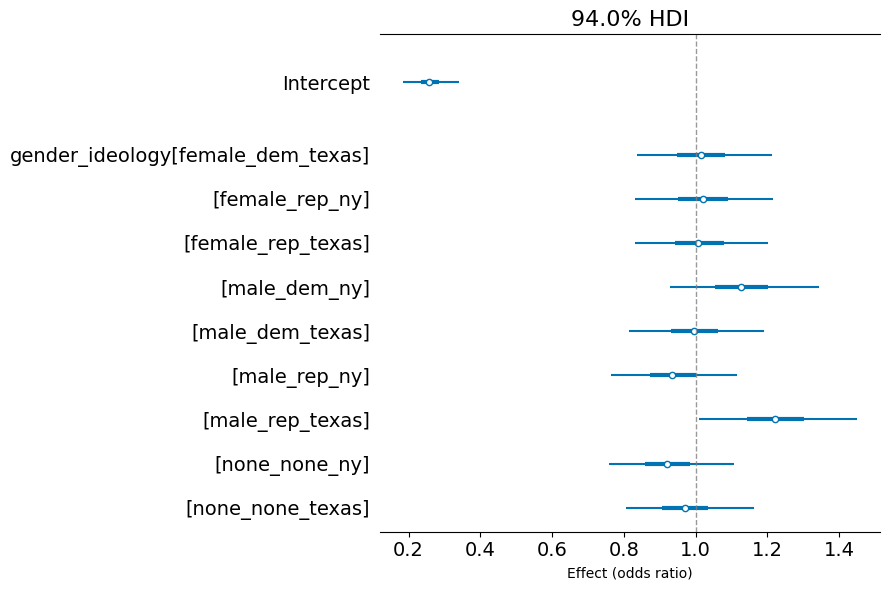

In [67]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ gender_ideology + (1|account) + (1|urlid)",
    data=reg_df,
    family="binomial",
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.99,
    chains=4
)
az.summary(results)


az.summary(
    results,
    # var_names=["Intercept", "gender", "political_ideology", "location", "ideology"]
)

axes = az.plot_forest(
    results,
    var_names=["Intercept", "gender_ideology"],
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(9, 6),
    r_hat=False,
    ess=False,
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")

plt.tight_layout()
plt.show()

In [71]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ gender_ideology : political_ideology + (1|account) + (1|urlid)",
    data=reg_df,
    family="binomial",
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.99,
    chains=4
)
az.summary(results)


az.summary(
    results,
    # var_names=["Intercept", "gender", "political_ideology", "location", "ideology"]
)

axes = az.plot_forest(
    results,
    var_names=["Intercept", "gender_ideology:political_ideology",],
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(9, 6),
    r_hat=False,
    ess=False,
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")

plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, political_ideology, gender_ideology:political_ideology, 1|account_sigma, 1|account_offset, 1|urlid_sigma, 1|urlid_offset]


Output()

EOFError: 

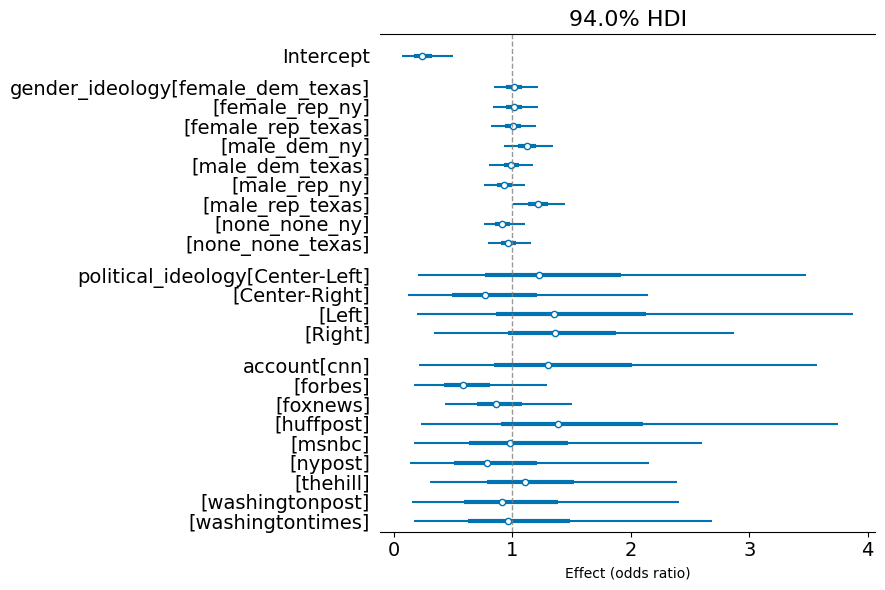

In [73]:
# model = bmb.Model(
#     "p(fcount_no_rank, ftrials_no_rank) ~ gender_ideology + political_ideology + account + (1|urlid)",
#     data=reg_df,
#     family="binomial",
# )

# results = model.fit(
#     draws=2000,      
#     tune=2000,       
#     target_accept=0.99,
#     chains=4
# )
# az.summary(results)


# az.summary(
#     results,
#     # var_names=["Intercept", "gender", "political_ideology", "location", "ideology"]
# )

axes = az.plot_forest(
    results,
    var_names=["Intercept", "gender_ideology", "political_ideology", "account"],
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(9, 6),
    r_hat=False,
    ess=False,
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")

plt.tight_layout()
plt.show()